In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Data preparation

In [2]:
# Load the results
df = pd.read_csv("results/results.csv")

# Shape should be 2 * 2 * (3 * 3 * 2 + 3) * 1000 = 84000
print(f"Shape: {df.shape}")
print(df.dtypes)

Shape: (84000, 13)
method                          str
replication_id                int64
ci_lower                    float64
ci_upper                    float64
bootstrap_seed                int64
library                         str
dgp                             str
statistic                       str
n                             int64
B                             int64
true_param_value            float64
nominal_1_sided_coverage    float64
nominal_2_sided_coverage    float64
dtype: object


In [3]:
df.head()

,method,replication_id,ci_lower,ci_upper,bootstrap_seed,library,dgp,statistic,n,B,true_param_value,nominal_1_sided_coverage,nominal_2_sided_coverage
0,percentile,0,0.009784,0.767302,2684470948,our,DGPNorm_0_1,mean,8,1000,0.0,0.975,0.95
1,percentile,1,-1.388232,-0.425091,4091952314,our,DGPNorm_0_1,mean,8,1000,0.0,0.975,0.95
2,percentile,2,-0.269031,0.655430,233227757,our,DGPNorm_0_1,mean,8,1000,0.0,0.975,0.95
3,percentile,3,-0.702347,0.180241,3276785861,our,DGPNorm_0_1,mean,8,1000,0.0,0.975,0.95
4,percentile,4,-0.077285,0.756373,3644269654,our,DGPNorm_0_1,mean,8,1000,0.0,0.975,0.95


In [4]:
# Create a pivot table to group the experiments ran under the same conditions (provided dataset, seed, ...)
paired = df.pivot(
    # Columns that uniquely identify each simulation run
    index=[
        "dgp",
        "statistic",
        "n",
        "B",
        "method",
        "replication_id",
        "true_param_value",
    ],
    # Columns to use to make the new frame's columns
    columns="library",
    # Columns to use to populate new frame's values
    values=["ci_lower", "ci_upper"],
)

# Rename the columns for easier access
paired.columns = ["_".join(part) for part in paired.columns]
paired = paired.reset_index()
paired

,dgp,statistic,n,B,method,replication_id,true_param_value,ci_lower_our,ci_lower_ref,ci_upper_our,ci_upper_ref
0,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,0,0.353553,-0.919196,-0.960065,0.942838,0.941861
1,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,1,0.353553,-0.873240,-0.903344,0.946342,0.974207
2,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,2,0.353553,-0.882933,-0.848619,0.950405,0.937014
3,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,3,0.353553,-0.664994,-0.830272,0.800456,0.809533
4,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,4,0.353553,-0.850192,-0.648945,0.879428,0.840967
...,...,...,...,...,...,...,...,...,...,...,...
41995,DGPNorm_0_1,median,128,1000,percentile,995,0.000000,-0.136874,-0.191949,0.219589,0.231727
41996,DGPNorm_0_1,median,128,1000,percentile,996,0.000000,-0.157515,-0.161845,0.274976,0.275254
41997,DGPNorm_0_1,median,128,1000,percentile,997,0.000000,-0.046484,-0.061066,0.365149,0.358169
41998,DGPNorm_0_1,median,128,1000,percentile,998,0.000000,-0.264359,-0.193272,0.313570,0.324828


In [5]:
# Seems like 2 experiments out of 42000 failed to produce a valid CI using our library
# the reference one may have produced valid CIs due to handling random numbers differently
paired.isna().sum()

dgp                 0
statistic           0
n                   0
B                   0
method              0
replication_id      0
true_param_value    0
ci_lower_our        2
ci_lower_ref        0
ci_upper_our        2
ci_upper_ref        0
dtype: int64

In [6]:
# The culprit is Pearson correlation for n = 8 and percentile method. Since
# computation can lead to division by 0 variance.
has_missing_endpoint = paired.isna().any(axis=1)
paired[has_missing_endpoint]

,dgp,statistic,n,B,method,replication_id,true_param_value,ci_lower_our,ci_lower_ref,ci_upper_our,ci_upper_ref
1505,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,percentile,505,0.353553,NaN,-0.308126,NaN,0.792564
1655,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,percentile,655,0.353553,NaN,-0.814943,NaN,0.932868


In [7]:
# Since it only happened in 2/1000 experiments for that setup (and for the percentile method),
# we will remove these results. (Drop rows that contain at least on missing value.)
paired_clean = paired.dropna().copy()
# We are left with 41998 rows
paired_clean

,dgp,statistic,n,B,method,replication_id,true_param_value,ci_lower_our,ci_lower_ref,ci_upper_our,ci_upper_ref
0,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,0,0.353553,-0.919196,-0.960065,0.942838,0.941861
1,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,1,0.353553,-0.873240,-0.903344,0.946342,0.974207
2,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,2,0.353553,-0.882933,-0.848619,0.950405,0.937014
3,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,3,0.353553,-0.664994,-0.830272,0.800456,0.809533
4,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,4,0.353553,-0.850192,-0.648945,0.879428,0.840967
...,...,...,...,...,...,...,...,...,...,...,...
41995,DGPNorm_0_1,median,128,1000,percentile,995,0.000000,-0.136874,-0.191949,0.219589,0.231727
41996,DGPNorm_0_1,median,128,1000,percentile,996,0.000000,-0.157515,-0.161845,0.274976,0.275254
41997,DGPNorm_0_1,median,128,1000,percentile,997,0.000000,-0.046484,-0.061066,0.365149,0.358169
41998,DGPNorm_0_1,median,128,1000,percentile,998,0.000000,-0.264359,-0.193272,0.313570,0.324828


## Coverage analysis

In [8]:
def covers_param(df, whose):
    df[f"lower_covers_{whose}"] = (
        df[f"ci_lower_{whose}"] <= df["true_param_value"]
    )
    df[f"upper_covers_{whose}"] = (
        df["true_param_value"] <= df[f"ci_upper_{whose}"]
    )
    df[f"two_sided_covers_{whose}"] = (
        df[f"lower_covers_{whose}"] & df[f"upper_covers_{whose}"]
    )


covers_param(paired_clean, "our")
covers_param(paired_clean, "ref")

paired_clean

,dgp,statistic,n,B,method,replication_id,true_param_value,ci_lower_our,ci_lower_ref,ci_upper_our,ci_upper_ref,lower_covers_our,upper_covers_our,two_sided_covers_our,lower_covers_ref,upper_covers_ref,two_sided_covers_ref
0,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,0,0.353553,-0.919196,-0.960065,0.942838,0.941861,True,True,True,True,True,True
1,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,1,0.353553,-0.873240,-0.903344,0.946342,0.974207,True,True,True,True,True,True
2,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,2,0.353553,-0.882933,-0.848619,0.950405,0.937014,True,True,True,True,True,True
3,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,3,0.353553,-0.664994,-0.830272,0.800456,0.809533,True,True,True,True,True,True
4,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,1000,double,4,0.353553,-0.850192,-0.648945,0.879428,0.840967,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,DGPNorm_0_1,median,128,1000,percentile,995,0.000000,-0.136874,-0.191949,0.219589,0.231727,True,True,True,True,True,True
41996,DGPNorm_0_1,median,128,1000,percentile,996,0.000000,-0.157515,-0.161845,0.274976,0.275254,True,True,True,True,True,True
41997,DGPNorm_0_1,median,128,1000,percentile,997,0.000000,-0.046484,-0.061066,0.365149,0.358169,True,True,True,True,True,True
41998,DGPNorm_0_1,median,128,1000,percentile,998,0.000000,-0.264359,-0.193272,0.313570,0.324828,True,True,True,True,True,True


In [9]:
coverage_summary = (
    paired_clean.groupby(by=["dgp", "statistic", "method", "n"])
    .agg(
        lower_coverage_our=("lower_covers_our", "mean"),
        lower_coverage_ref=("lower_covers_ref", "mean"),
        upper_coverage_our=("upper_covers_our", "mean"),
        upper_coverage_ref=("upper_covers_ref", "mean"),
        two_sided_coverage_our=("two_sided_covers_our", "mean"),
        two_sided_coverage_ref=("two_sided_covers_ref", "mean"),
        repetitions=("replication_id", "count"),
    )
    .reset_index()
)
coverage_summary["lower_coverage_diff"] = (
    coverage_summary["lower_coverage_our"]
    - coverage_summary["lower_coverage_ref"]
)
coverage_summary["upper_coverage_diff"] = (
    coverage_summary["upper_coverage_our"]
    - coverage_summary["upper_coverage_ref"]
)
coverage_summary["two_sided_coverage_diff"] = (
    coverage_summary["two_sided_coverage_our"]
    - coverage_summary["two_sided_coverage_ref"]
)

coverage_summary

,dgp,statistic,method,n,lower_coverage_our,lower_coverage_ref,upper_coverage_our,upper_coverage_ref,two_sided_coverage_our,two_sided_coverage_ref,repetitions,lower_coverage_diff,upper_coverage_diff,two_sided_coverage_diff
0,DGPBiNorm-1_1_2.0_0.5_1.0,corr,double,8,0.995000,0.997000,0.998000,0.995000,0.993000,0.9920,1000,-0.002,0.003000,0.001000
1,DGPBiNorm-1_1_2.0_0.5_1.0,corr,double,32,0.980000,0.983000,0.982000,0.979000,0.962000,0.9620,1000,-0.003,0.003000,0.000000
2,DGPBiNorm-1_1_2.0_0.5_1.0,corr,double,128,0.971000,0.968000,0.966000,0.966000,0.937000,0.9340,1000,0.003,0.000000,0.003000
3,DGPBiNorm-1_1_2.0_0.5_1.0,corr,percentile,8,0.932866,0.932866,0.967936,0.966934,0.900802,0.8998,998,0.000,0.001002,0.001002
4,DGPBiNorm-1_1_2.0_0.5_1.0,corr,percentile,32,0.962000,0.960000,0.974000,0.974000,0.936000,0.9340,1000,0.002,0.000000,0.002000
5,DGPBiNorm-1_1_2.0_0.5_1.0,corr,percentile,128,0.964000,0.963000,0.972000,0.963000,0.936000,0.9260,1000,0.001,0.009000,0.010000
6,DGPExp_1,mean,double,8,0.997000,0.997000,0.927000,0.928000,0.924000,0.9250,1000,0.000,-0.001000,-0.001000
7,DGPExp_1,mean,double,32,0.979000,0.979000,0.971000,0.971000,0.950000,0.9500,1000,0.000,0.000000,0.000000
8,DGPExp_1,mean,double,128,0.971000,0.975000,0.972000,0.967000,0.943000,0.9420,1000,-0.004,0.005000,0.001000
9,DGPExp_1,mean,percentile,8,0.991000,0.990000,0.855000,0.852000,0.846000,0.8420,1000,0.001,0.003000,0.004000


In [10]:
# What are the differences in coverage like in general over all methods
def get_diff_summary_by_method(df, bound):
    return (
        # Group rows by method and only select the bound column
        df.groupby("method")[bound]
        .agg(
            mean_difference="mean",
            mean_absolute_difference=lambda x: x.abs().mean(),
            max_absolute_difference=lambda x: x.abs().max(),
        )
        .T
    )


# Lower coverage
get_diff_summary_by_method(coverage_summary, "lower_coverage_diff")

method,double,percentile
mean_difference,-0.001095,0.001476
mean_absolute_difference,0.002714,0.002238
max_absolute_difference,0.006000,0.006000


In [11]:
# Upper coverage
get_diff_summary_by_method(coverage_summary, "upper_coverage_diff")

method,double,percentile
mean_difference,0.000762,0.000524
mean_absolute_difference,0.001810,0.002333
max_absolute_difference,0.005000,0.009000


In [12]:
# Two sided coverage
get_diff_summary_by_method(coverage_summary, "two_sided_coverage_diff")

method,double,percentile
mean_difference,-0.000333,0.002000
mean_absolute_difference,0.002333,0.003905
max_absolute_difference,0.009000,0.010000


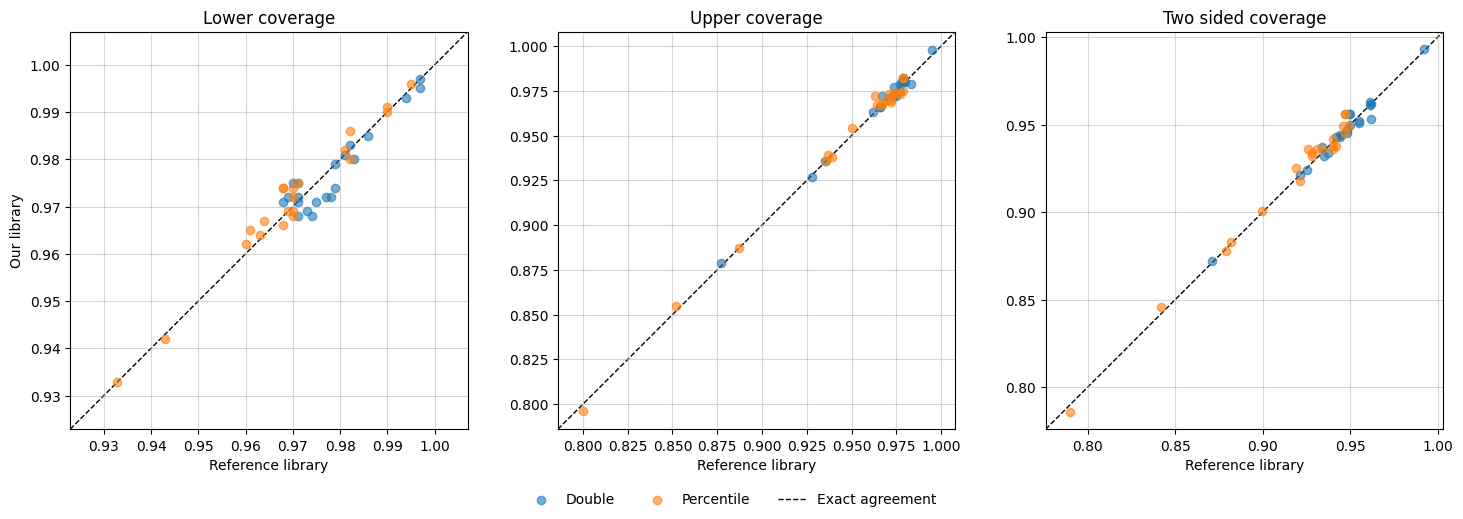

In [13]:
coverage_specs = {
    "lower_coverage": 0.975,
    "upper_coverage": 0.975,
    "two_sided_coverage": 0.95,
}

# Plot the coverage agreement of the libraries
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

for j, (coverage, nominal) in enumerate(coverage_specs.items()):
    x = coverage_summary[f"{coverage}_ref"]
    y = coverage_summary[f"{coverage}_our"]

    for method in ("double", "percentile"):
        our_coverage = coverage_summary[(coverage_summary["method"] == method)][
            f"{coverage}_our"
        ].to_numpy()
        ref_coverage = coverage_summary[(coverage_summary["method"] == method)][
            f"{coverage}_ref"
        ].to_numpy()

        ax[j].scatter(
            ref_coverage,
            our_coverage,
            alpha=0.6,
            label=method.capitalize(),
            zorder=2,
        )

    lower_limit = min(x.min(), y.min()) - 0.01
    upper_limit = max(x.max(), y.max()) + 0.01

    ax[j].set(
        xlim=(lower_limit, upper_limit),
        ylim=(lower_limit, upper_limit),
        xlabel="Reference library",
        aspect="equal",
    )

    if j == 0:
        ax[j].set_ylabel("Our library")

    ax[j].set_title(
        f"{coverage.replace('_', ' ').capitalize()}",
    )

    ax[j].plot(
        (lower_limit, upper_limit),
        (lower_limit, upper_limit),
        color="black",
        linestyle="--",
        linewidth=1,
        label="Exact agreement",
        zorder=1,
    )

    ax[j].grid(alpha=0.5)

handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3,
    frameon=False,
)

fig.tight_layout(rect=[0, 0.10, 1, 1])

In [14]:
# Quantifying uncertainty in differences in coverage of both libraries

# Use a mature bootstrap implementation
from scipy.stats import bootstrap

# Since experiments are paired, we compute differences between libraries
# so we can only resample those
paired_clean["coverage_diff_lower"] = paired_clean["lower_covers_our"].astype(
    int
) - paired_clean["lower_covers_ref"].astype(int)

paired_clean["coverage_diff_upper"] = paired_clean["upper_covers_our"].astype(
    int
) - paired_clean["upper_covers_ref"].astype(int)

paired_clean["coverage_diff_two_sided"] = paired_clean[
    "two_sided_covers_our"
].astype(int) - paired_clean["two_sided_covers_ref"].astype(int)

In [15]:
# These values define different experiment configurations -> for each
# configuration, we want to report uncertainty in the difference in coverages
group_cols = ["dgp", "statistic", "n", "method"]

results = []

for group_values, group_df in paired_clean.groupby(group_cols):
    # store metadata
    row = {col: val for col, val in zip(group_cols, group_values)}  # ty:ignore[not-iterable]

    for coverage_type in ["lower", "upper", "two_sided"]:
        coverage_diff = group_df[f"coverage_diff_{coverage_type}"]

        # CI for difference in converage
        cd_ci = bootstrap(
            (coverage_diff,),
            np.mean,
            n_resamples=10_000,
            confidence_level=0.95,
            method="BCa",
            rng=np.random.default_rng(0),
        )

        low, high = cd_ci.confidence_interval
        row[f"{coverage_type}_CI_low"] = low
        row[f"{coverage_type}_CI_high"] = high

    results.append(row)

coverage_ci_df = pd.DataFrame(results)

In [16]:
def does_not_contain_0(df):
    mask = np.zeros(len(df))

    for bound in ["lower", "upper", "two_sided"]:
        mask = mask | (df[f"{bound}_CI_low"] > 0) | (df[f"{bound}_CI_high"] < 0)

    return mask

In [17]:
coverage_ci_double = coverage_ci_df[
    coverage_ci_df["method"] == "double"
].reset_index(drop=True)

coverage_ci_double

,dgp,statistic,n,method,lower_CI_low,lower_CI_high,upper_CI_low,upper_CI_high,two_sided_CI_low,two_sided_CI_high
0,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,double,-0.007,0.002000,-0.001,0.008,-0.006,0.007
1,DGPBiNorm-1_1_2.0_0.5_1.0,corr,32,double,-0.008,0.001000,-0.001,0.008,-0.006,0.006
2,DGPBiNorm-1_1_2.0_0.5_1.0,corr,128,double,-0.003,0.009000,-0.007,0.007,-0.006,0.012
3,DGPExp_1,mean,8,double,-0.003,0.003000,-0.009,0.007,-0.009,0.007
4,DGPExp_1,mean,32,double,-0.007,0.006878,-0.006,0.005,-0.009,0.008
5,DGPExp_1,mean,128,double,-0.011,0.002000,-0.002,0.013,-0.009,0.011
6,DGPExp_1,median,8,double,-0.012,0.000000,-0.012,0.004,-0.019,0.001
7,DGPExp_1,median,32,double,-0.013,-0.001000,-0.003,0.010,-0.012,0.005
8,DGPExp_1,median,128,double,-0.004,0.007000,-0.008,0.003,-0.009,0.007
9,DGPLogNorm_0_1,mean,8,double,-0.005,0.002000,-0.006,0.010,-0.007,0.010


In [18]:
mask = does_not_contain_0(coverage_ci_double)

coverage_ci_double[mask]

,dgp,statistic,n,method,lower_CI_low,lower_CI_high,upper_CI_low,upper_CI_high,two_sided_CI_low,two_sided_CI_high
7,DGPExp_1,median,32,double,-0.013,-0.001,-0.003,0.010,-0.012,0.005
13,DGPLogNorm_0_1,median,32,double,-0.011,-0.001,-0.003,0.008,-0.011,0.004
14,DGPLogNorm_0_1,median,128,double,0.001,0.011,-0.002,0.007,0.001,0.015
19,DGPNorm_0_1,median,32,double,-0.013,-0.001,-0.003,0.008,-0.013,0.004


In [19]:
coverage_ci_percentile = coverage_ci_df[
    coverage_ci_df["method"] == "percentile"
].reset_index(drop=True)

coverage_ci_percentile

,dgp,statistic,n,method,lower_CI_low,lower_CI_high,upper_CI_low,upper_CI_high,two_sided_CI_low,two_sided_CI_high
0,DGPBiNorm-1_1_2.0_0.5_1.0,corr,8,percentile,-0.007014,0.007014,-0.003006,0.006012,-0.007014,0.01002
1,DGPBiNorm-1_1_2.0_0.5_1.0,corr,32,percentile,-0.004000,0.009000,-0.003000,0.003000,-0.005000,0.00900
2,DGPBiNorm-1_1_2.0_0.5_1.0,corr,128,percentile,-0.004000,0.006000,0.004000,0.017000,0.003000,0.01900
3,DGPExp_1,mean,8,percentile,0.000000,0.006000,-0.004000,0.011000,-0.003000,0.01200
4,DGPExp_1,mean,32,percentile,-0.007000,0.000000,-0.006000,0.004000,-0.009000,0.00200
5,DGPExp_1,mean,128,percentile,-0.003000,0.006000,0.000000,0.010000,-0.001000,0.01200
6,DGPExp_1,median,8,percentile,-0.002000,0.009000,0.001000,0.008615,0.001000,0.01300
7,DGPExp_1,median,32,percentile,-0.004000,0.004000,-0.001000,0.007000,-0.003000,0.00800
8,DGPExp_1,median,128,percentile,0.000000,0.007000,-0.010000,0.000000,-0.008000,0.00300
9,DGPLogNorm_0_1,mean,8,percentile,-0.004000,0.004000,-0.010939,0.001000,-0.011000,0.00300


In [20]:
mask = does_not_contain_0(coverage_ci_percentile)

coverage_ci_percentile[mask]

,dgp,statistic,n,method,lower_CI_low,lower_CI_high,upper_CI_low,upper_CI_high,two_sided_CI_low,two_sided_CI_high
2,DGPBiNorm-1_1_2.0_0.5_1.0,corr,128,percentile,-0.004,0.006,0.004,0.017000,0.003,0.019
6,DGPExp_1,median,8,percentile,-0.002,0.009,0.001,0.008615,0.001,0.013
14,DGPLogNorm_0_1,median,128,percentile,0.001,0.013,0.001,0.009000,0.003,0.017
20,DGPNorm_0_1,median,128,percentile,0.001,0.013,0.001,0.009000,0.003,0.017


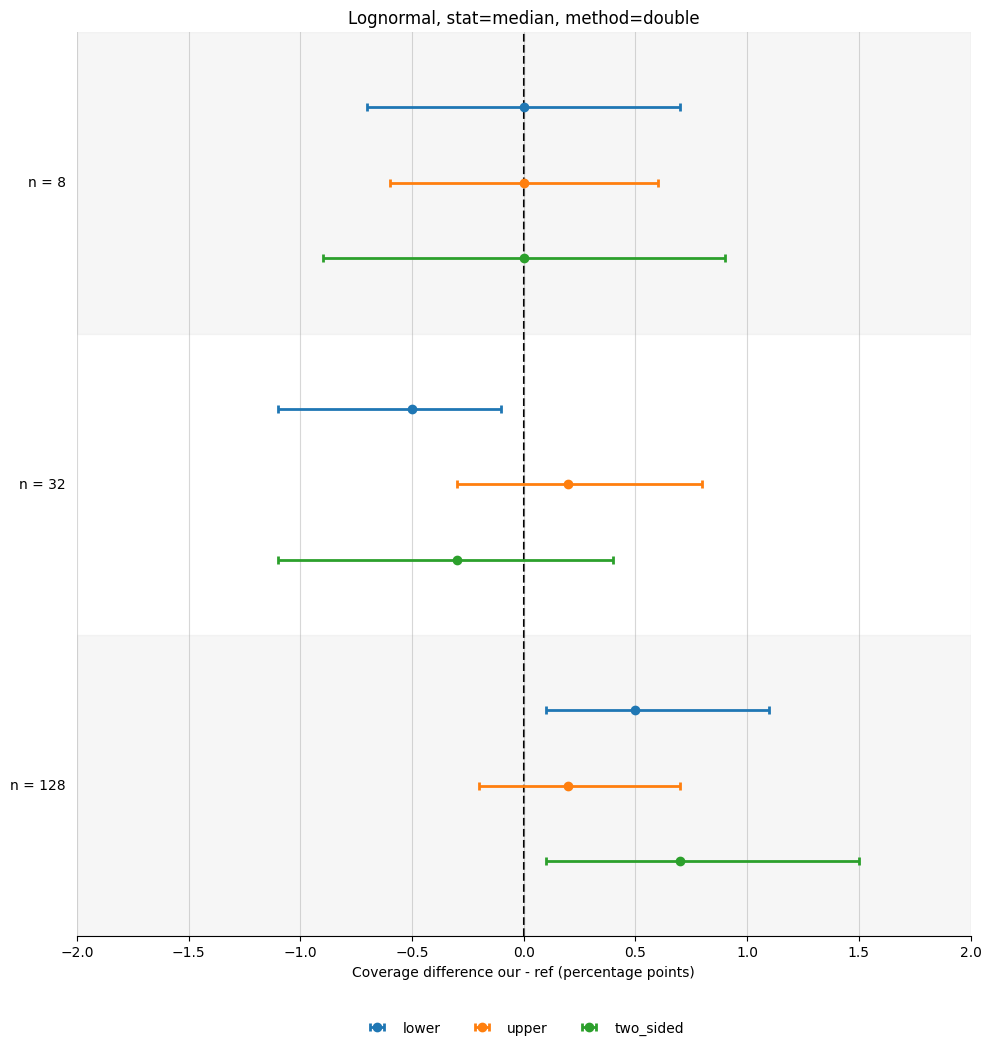

In [118]:
group_cols = [
    "dgp",
    "statistic",
    "n",
    "method",
]

# Merge data frames to have coverage differences and CIs for differences in the same
# data frame
plot_df = coverage_summary.merge(coverage_ci_df, on=group_cols)

# Convert coverage differences and CIs to percentage points
plot_df[
    ["lower_coverage_diff", "upper_coverage_diff", "two_sided_coverage_diff"]
] *= 100
for bound in ["lower", "upper", "two_sided"]:
    plot_df[[f"{bound}_CI_low", f"{bound}_CI_high"]] *= 100


def plot_results(
    dgp_name,
    statistic,
    method,
):
    dgp_map = {
        "normal": "DGPNorm_0_1",
        "bivariate normal": "DGPBiNorm-1_1_2.0_0.5_1.0",
        "exponential": "DGPExp_1",
        "lognormal": "DGPLogNorm_0_1",
    }
    dgp = dgp_map[dgp_name]

    df_subset = plot_df[
        (plot_df["dgp"] == dgp)
        & (plot_df["statistic"] == statistic)
        & (plot_df["method"] == method)
    ]

    ns = df_subset["n"].unique()

    # 3 groups (lower, upper and two_sided)
    centers = [5, 3, 1]

    fig, ax = plt.subplots(figsize=(10, 10))

    ax.set_title(f"{dgp_name.capitalize()}, stat={statistic}, method={method}")

    bound_to_color = {
        "lower": "tab:blue",
        "upper": "tab:orange",
        "two_sided": "tab:green",
    }

    for n, y in zip(ns, centers):
        for bound in bound_to_color.keys():
            data_row = df_subset[df_subset["n"] == n]

            coverage_diff = data_row[f"{bound}_coverage_diff"]
            low = data_row[f"{bound}_CI_low"]
            high = data_row[f"{bound}_CI_high"]

            if bound == "lower":
                height = y + 0.5
            elif bound == "two_sided":
                height = y - 0.5
            else:
                height = y

            # Erorrbars for all bounds (lower, upper, two_sided)
            ax.errorbar(
                x=coverage_diff,
                xerr=(coverage_diff - low, high - coverage_diff),
                y=height,
                elinewidth=2,
                capsize=3,
                capthick=2,
                ecolor=bound_to_color[bound],
                color=bound_to_color[bound],
                fmt="o",
                zorder=2,
                label=bound,
            )

    ax.set_xlim(-2, 2)
    ax.set_ylim(0, 6)
    ax.axvline(0, linestyle="--", color="black", zorder=1, linewidth=1.5)
    ax.set_xlabel("Coverage difference our - ref (percentage points)")
    ax.set_ylabel("Sample size")
    ax.set_yticks(centers, ns)

    for i, spine in enumerate(ax.spines.values()):
        if i != 2:
            spine.set_visible(False)

    ax.grid(alpha=0.5)
    ax.yaxis.set_visible(False)

    for y_pos, n in zip(centers, ns):
        ax.text(
            -2.05,
            y_pos,
            f"n = {n}",
            ha="right",
            va="center",
            clip_on=False,
        )

    for i, center in enumerate(centers):
        if i % 2 == 0:
            ax.axhspan(
                center - 1,
                center + 1,
                alpha=0.20,
                zorder=0,
                color="lightgray",
            )

    fig.tight_layout()

    handles, labels = ax.get_legend_handles_labels()

    unique = dict(zip(labels, handles))

    ax.legend(
        unique.values(),
        unique.keys(),
        loc="upper center",
        bbox_to_anchor=(0.5, -0.08),
        ncol=3,
        frameon=False,
    )


plot_results("lognormal", "median", "double")

## Endpoint analysis

In [133]:
# Compute endpoint differences
endpoint_df = paired_clean.copy()

endpoint_df["ci_lower_diff"] = (
    endpoint_df["ci_lower_our"] - endpoint_df["ci_lower_ref"]
)
paired_clean["ci_upper_diff"] = (
    endpoint_df["ci_upper_our"] - endpoint_df["ci_upper_ref"]
)

In [134]:
# Lower endpoint
endpoint_df.groupby("method")["ci_lower_diff"].agg(
    mean_lower_diff="mean",
    mean_absolute_lower_diff=lambda x: x.abs().mean(),
    max_absolute_lower_diff=lambda x: x.abs().max(),
).T

method,double,percentile
mean_lower_diff,0.003727,-0.000506
mean_absolute_lower_diff,0.032709,0.020573
max_absolute_lower_diff,1.625690,0.985969


In [ ]:
# Upper endpoint
endpoint_df.groupby("method")["ci_upper_diff"].agg(
    mean_upper_diff="mean",
    mean_absolute_upper_diff=lambda x: x.abs().mean(),
    max_absolute_upper_diff=lambda x: x.abs().max(),
).T

method,double,percentile
mean_upper_diff,0.008790,-0.001509
mean_absolute_upper_diff,0.082932,0.029883
max_absolute_upper_diff,16.565349,4.649276
